# Phase 3 : Analyse Multivariée et Corrélations (Volet 2)

## Introduction
Dans cette troisième partie, nous exploitons notre jeu de données nettoyé pour mener une analyse statistique approfondie. L'objectif de ce "Volet 2" est d'extraire des informations pertinentes et de comprendre les relations entre nos différentes variables, en particulier ce qui influence notre variable cible : le `Taux_Chlordecone`.

---

### 1. Matrice de corrélation et Carte de Chaleur (Heatmap)
 l'outil privilégié pour analyser les relations entre *plusieurs variables quantitatives* est la **Carte de chaleur (Heatmap)**. 

Nous allons charger nos données propres, isoler les variables numériques (en excluant les identifiants et les années qui n'ont pas de sens mathématique ici), et calculer le coefficient de corrélation linéaire (Pearson). Cela nous permettra d'identifier d'un seul coup d'œil quelles variables topographiques ou historiques sont liées à la présence de chlordécone.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Chargement du dataset de données propres 
df = pd.read_csv('chlordecone_Clean.csv')
df.head()

,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,0.07,2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,0.07,2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,0.07,3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,0.07,1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,0.07,2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


In [11]:
#2. Sélection des variables quantitatives pour l'analyse multivariée ( ID et ANNEE sont exclus)
colonnes_num = df.select_dtypes(include=['float64', 'int64']).columns
colonnes_a_garder = [col for col in colonnes_num if col not in ['ID', 'ANNEE']]
df_num = df[colonnes_a_garder]

df_num.head()

,Taux_Chlordecone,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,4.6,0.07,2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,4.6,0.07,2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,4.6,0.07,3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,4.6,0.07,1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,4.6,0.07,2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


In [15]:
#3. matrice de corrélation
matrice_corr = df_num.corr()
matrice_corr

,Taux_Chlordecone,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
Taux_Chlordecone,1.000000,-0.010614,0.363904,-0.042858,0.059497,0.043426,0.030203,0.053972,0.036437,-0.311115,0.286264
Taux_5b_hydro,-0.010614,1.000000,0.031951,0.007689,0.006228,0.011514,-0.021200,0.014806,0.009777,0.043523,-0.033310
histoBanane_Histo_ban,0.363904,0.031951,1.000000,-0.005903,0.010162,0.009094,0.021964,0.023744,0.008355,-0.012192,0.180969
mnt_tpi_mean,-0.042858,0.007689,-0.005903,1.000000,0.020793,0.047929,-0.026580,-0.011207,0.028404,-0.070118,0.069622
mnt_tri_mean,0.059497,0.006228,0.010162,0.020793,1.000000,0.971321,-0.133361,0.086087,0.962995,-0.122425,0.076021
mnt_rugosite_mean,0.043426,0.011514,0.009094,0.047929,0.971321,1.000000,-0.135629,0.091133,0.968926,-0.109272,0.064203
mnt_ombrage_mean,0.030203,-0.021200,0.021964,-0.026580,-0.133361,-0.135629,1.000000,0.439395,-0.146921,0.005611,-0.020576
mnt_exposition_mean,0.053972,0.014806,0.023744,-0.011207,0.086087,0.091133,0.439395,1.000000,0.085445,-0.005242,-0.092235
mnt_pente_mean,0.036437,0.009777,0.008355,0.028404,0.962995,0.968926,-0.146921,0.085445,1.000000,-0.097648,0.056794
X,-0.311115,0.043523,-0.012192,-0.070118,-0.122425,-0.109272,0.005611,-0.005242,-0.097648,1.000000,-0.772742


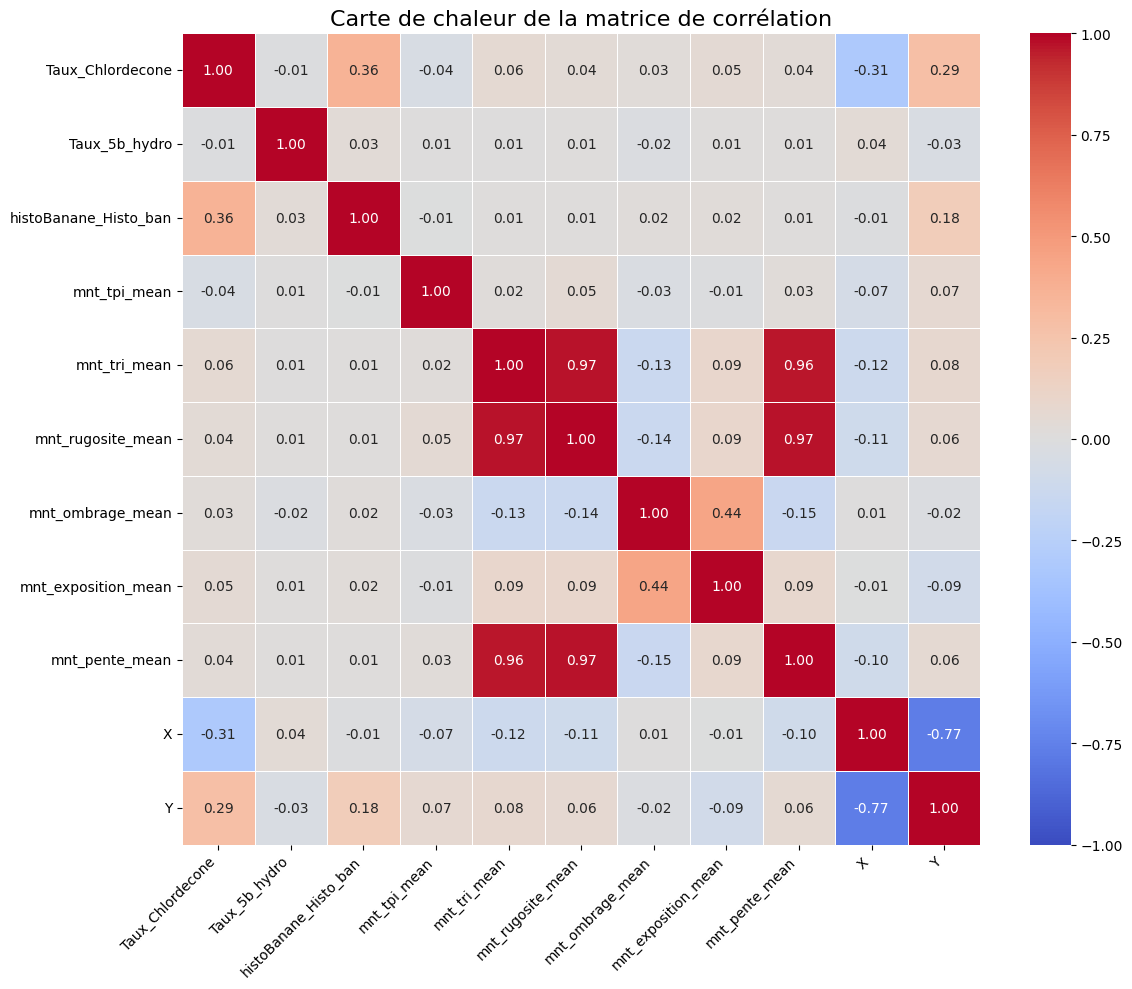

In [17]:
#4 carte de chaleur de la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(
    matrice_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5
)

plt.title('Carte de chaleur de la matrice de corrélation', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2. Interprétation de la Carte de Chaleur
L'analyse de la matrice de corrélation linéaire de Pearson met en évidence plusieurs points clés concernant notre variable cible (`Taux_Chlordecone`) :
* **Facteur agronomique** : La variable `histoBanane_Histo_ban` présente la plus forte corrélation positive (0.36). Cela valide l'hypothèse métier selon laquelle la chlordécone était massivement utilisée sur les bananeraies.
* **Facteur spatial** : Les coordonnées géographiques X (-0.31) et Y (0.29) montrent une corrélation modérée, suggérant que la contamination est géographiquement localisée (formation potentielle de clusters spatiaux).
* **Facteurs topographiques** : Les variables de terrain (pente, rugosité, etc.) ont des coefficients proches de zéro, indiquant une absence de lien linéaire direct avec le niveau de contamination.

---

### 3. Analyse en Composantes Principales (ACP) - Préparation et Variance
Pour approfondir notre analyse multivariée (Volet 2) et comprendre comment toutes nos variables quantitatives interagissent entre elles, nous allons réaliser une **Analyse en Composantes Principales (ACP)**.

La première étape indispensable de l'ACP est la **standardisation des données** (centrage et réduction), car nos variables ont des échelles très différentes (des coordonnées en millions et des taux très petits). 
Ensuite, nous calculerons l'ACP et afficherons le graphique de la **variance expliquée cumulée** (l'éboulis des valeurs propres) pour décider combien d'axes factoriels (composantes) nous devons retenir pour résumer notre information.

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

In [19]:
#1. Standardisation des données quantitatives (centrage et réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print("Données standardisées (premières lignes) :", X_scaled[:5])

Données standardisées (premières lignes) : [[ 2.48137849 -0.06706221  1.35860364  2.15905091  1.29313921  0.93848345
  -1.56566835 -0.9494143   1.39588212  0.13005504  0.1936979 ]
 [ 2.48137849 -0.06706221  1.35860364  2.11175482  1.25378901  0.86339309
  -1.44281194 -0.97516606  1.32726789  0.1303496   0.19458605]
 [ 2.48137849 -0.06706221  2.40809648  0.78067364  0.97048626  0.76396608
  -1.27065457 -0.9847981   1.0924154   0.13092663  0.19512902]
 [ 2.48137849 -0.06706221  0.3091108   1.47591492  1.11757693  1.15076806
  -1.90803999 -0.81403333  1.34160544  0.12938494  0.19181019]
 [ 2.48137849 -0.06706221  1.35860364  0.14570744  0.80606086  0.77182374
  -1.46224235 -0.90253212  1.01040344  0.13035767  0.19344729]]


In [20]:
#2. Création de l'objet PCA et ajustement aux données

pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [21]:
#3. Calcul de la variance expliquée cumulée

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)*100
print("Variance expliquée cumulée par les composantes principales :", variance_cumulee)

Variance expliquée cumulée par les composantes principales : [ 27.49450959  45.60828932  58.90690098  69.50798855  78.69764956
  87.36804955  92.92377289  97.65539919  99.42307336  99.75610833
 100.        ]


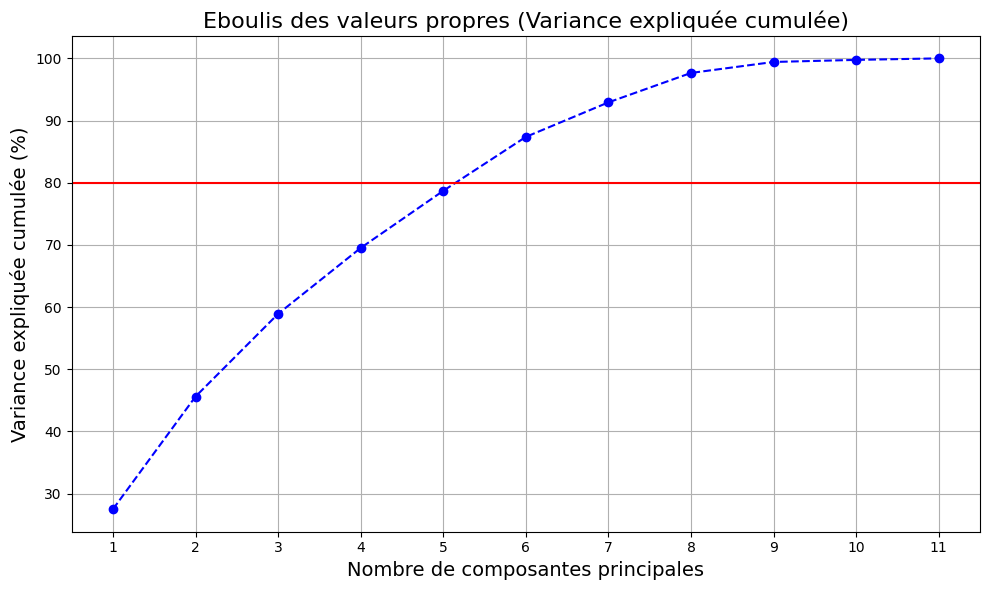

In [22]:
#4. graphique de la variance expliquée cumulée
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker='o', linestyle='--',color ='b')
plt.axhline(y=80, color='r', linestyle='-')
plt.title('Eboulis des valeurs propres (Variance expliquée cumulée)', fontsize=16)
plt.xlabel('Nombre de composantes principales', fontsize=14)
plt.ylabel('Variance expliquée cumulée (%)', fontsize=14)
plt.xticks(range(1, len(variance_cumulee) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### 4. Interprétation de l'éboulis des valeurs propres
L'analyse de la variance expliquée cumulée (éboulis) nous montre que :
* 5 composantes principales résument à elles seules près de **78.7%** de l'information initiale.
* Il faut **6 composantes** pour dépasser formellement le seuil de rétention des **80%** (87.3%).

C'est une excellente performance de réduction de dimension. Plutôt que d'étudier 11 variables quantitatives de manière isolée, nous pouvons désormais concentrer notre analyse sur ces nouveaux axes majeurs.

---

### 5. Le Cercle des Corrélations (Axes F1 et F2)
Afin de comprendre la signification sémantique de ces nouvelles composantes principales, nous construisons le **Cercle des corrélations** sur les deux premiers axes (F1 et F2). 

Ce graphique permet de :
1. Visualiser quelles variables initiales contribuent le plus à la formation des axes principaux (les flèches proches du bord du cercle).
2. Identifier des groupes de variables fortement corrélées entre elles (flèches pointant dans la même direction).
3. Confirmer visuellement les relations avec notre variable cible `Taux_Chlordecone`.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#1. Calcul des coordonnées des variables (corrélations avec les axes F1 et F2 )
#Formule :  vecteur_propre * racine(valeur_propre)

racine_valeurs_propres = np.sqrt(pca.explained_variance_)
correlations = pca.components_ * racine_valeurs_propres[:, np.newaxis]

print("Corrélations des variables avec les axes F1 et F2 :\n", correlations[:2])

Corrélations des variables avec les axes F1 et F2 :
 [[ 0.149022    0.00664049  0.06059638  0.06231702  0.97312685  0.97300623
  -0.18298749  0.08121433  0.96846009 -0.2696607   0.22418839]
 [ 0.60871809 -0.06444307  0.38032154  0.06936323 -0.1614168  -0.17709919
   0.0525771  -0.05730574 -0.18747735 -0.80569919  0.84892214]]


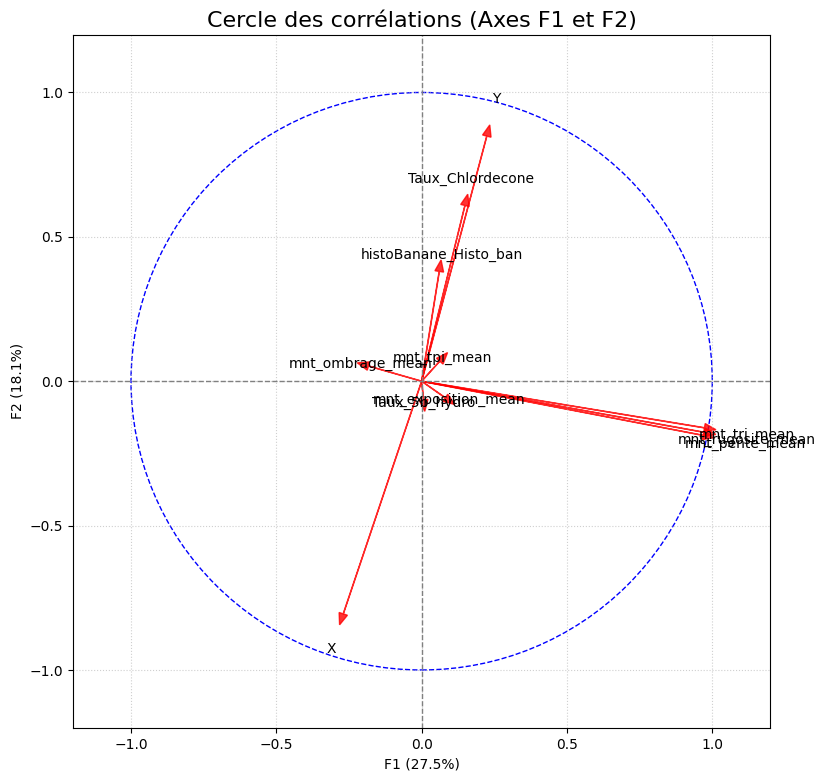

In [30]:
# 2. Création de la figure
fig, ax = plt.subplots(figsize=(9, 9))

# 3. Tracé du cercle unitaire
cercle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
ax.add_artist(cercle)

# 4. Affichage des flèches pour chaque variable
for i, nom_variable in enumerate(colonnes_a_garder):
    ax.arrow(0, 0, correlations[0, i], correlations[1, i], 
             head_width=0.03, head_length=0.04, fc='red', ec='red', alpha=0.8)
    
    # Placement des étiquettes (noms des variables) légèrement décalées de la flèche
    ax.text(correlations[0, i] * 1.15, correlations[1, i] * 1.15, 
            nom_variable, color='black', ha='center', va='center', fontsize=10)

# 5. Esthétique du graphique (lignes 0, limites, titres)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

# Titre avec la variance expliquée par les axes 1 et 2
var_f1 = pca.explained_variance_ratio_[0] * 100
var_f2 = pca.explained_variance_ratio_[1] * 100
plt.title("Cercle des corrélations (Axes F1 et F2)", fontsize=16)
plt.xlabel(f"F1 ({var_f1:.1f}%)")
plt.ylabel(f"F2 ({var_f2:.1f}%)")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

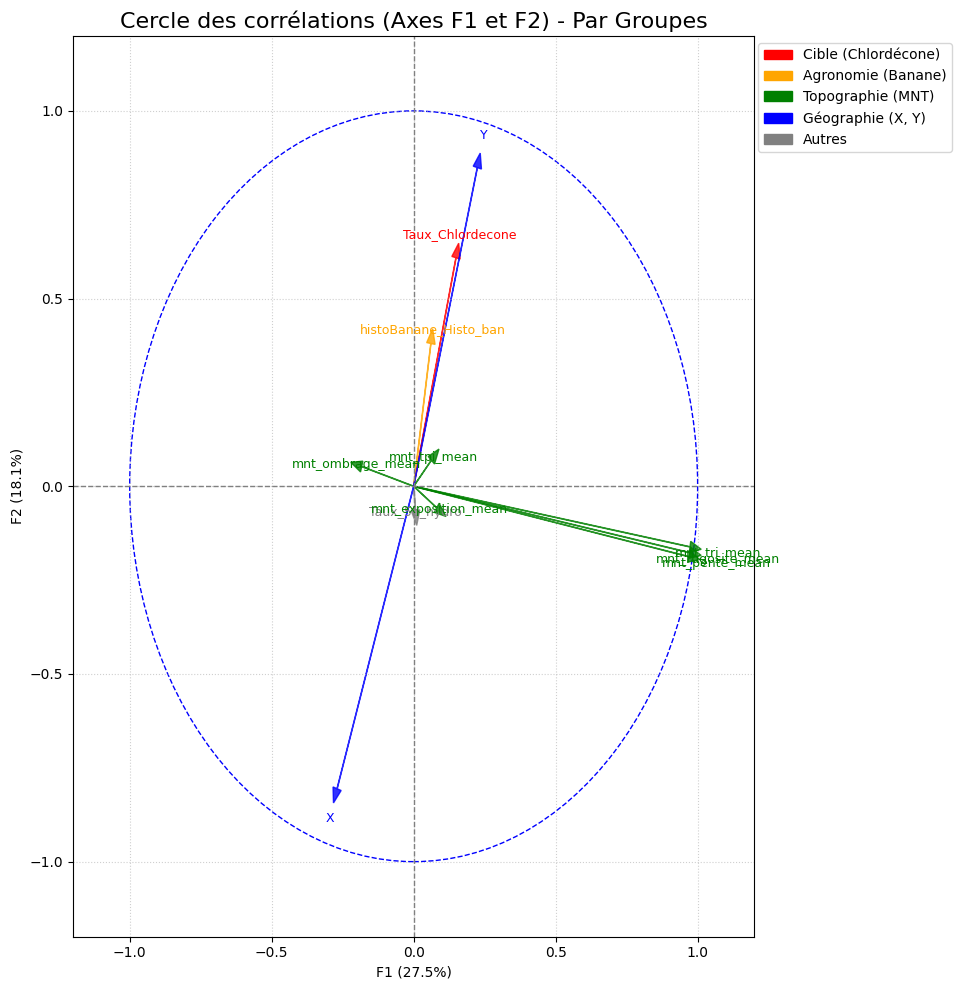

In [32]:
import matplotlib.patches as mpatches

# 1. Calcul des coordonnées des variables (si ce n'est pas déjà en mémoire)
racine_valeurs_propres = np.sqrt(pca.explained_variance_)
correlations = pca.components_ * racine_valeurs_propres[:, np.newaxis]

# 2. Définition des groupes et de leurs couleurs
couleurs_groupes = {
    'Taux_Chlordecone': 'red',       # Cible
    'histoBanane_Histo_ban': 'orange', # Historique agricole
    'X': 'blue', 'Y': 'blue',        # Géographie spatiale
    'Taux_5b_hydro': 'grey'          # Autre
}
# Toutes les variables qui commencent par 'mnt_' (Topographie) seront en vert
couleur_topo = 'green'

# 3. Création de la figure
fig, ax = plt.subplots(figsize=(10, 10))
cercle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
ax.add_artist(cercle)

# 4. Tracé des flèches avec le code couleur
for i, nom_variable in enumerate(colonnes_a_garder):
    # Choix de la couleur
    if nom_variable.startswith('mnt_'):
        couleur = couleur_topo
    else:
        couleur = couleurs_groupes.get(nom_variable, 'grey')
        
    ax.arrow(0, 0, correlations[0, i], correlations[1, i], 
             head_width=0.03, head_length=0.04, fc=couleur, ec=couleur, alpha=0.8)
    
    # On affiche le texte avec la même couleur pour faciliter la lecture
    ax.text(correlations[0, i] * 1.1, correlations[1, i] * 1.1, 
            nom_variable, color=couleur, ha='center', va='center', fontsize=9)

# 5. Création de la légende personnalisée
legendes = [
    mpatches.Patch(color='red', label='Cible (Chlordécone)'),
    mpatches.Patch(color='orange', label='Agronomie (Banane)'),
    mpatches.Patch(color='green', label='Topographie (MNT)'),
    mpatches.Patch(color='blue', label='Géographie (X, Y)'),
    mpatches.Patch(color='grey', label='Autres')
]
# On place la légende en dehors du cercle pour ne rien cacher
plt.legend(handles=legendes, loc='upper right', bbox_to_anchor=(1.3, 1))

# 6. Esthétique du graphique
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

var_f1 = pca.explained_variance_ratio_[0] * 100
var_f2 = pca.explained_variance_ratio_[1] * 100
plt.title("Cercle des corrélations (Axes F1 et F2) - Par Groupes", fontsize=16)
plt.xlabel(f"F1 ({var_f1:.1f}%)")
plt.ylabel(f"F2 ({var_f2:.1f}%)")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 5.bis Qualité de représentation (Cos2) et Contributions
Avant de clore l'Analyse en Composantes Principales et de passer au clustering, il est indispensable de valider notre lecture du cercle des corrélations de manière numérique. 

nous allons extraire pour nos deux premiers axes (F1 et F2) :
1. **Les corrélations** : le lien brut avec les axes.
2. **Le Cos² (Qualité de représentation)** : pour s'assurer que nos variables sont bien projetées sur ce plan 2D et que notre interprétation visuelle est fiable.
3. **Les contributions (%)** : pour identifier les variables qui ont le plus de poids dans la construction de chaque axe.

In [ ]:
#1 Calcul des coordonnées des variables (corrélations avec les axes F1 et F2 )
df_cor = pd.DataFrame(correlations[:2].T, columns=['Corr_F1', 'Corr_F2'], index=colonnes_a_garder)
print(df_cor)

                        Corr_F1   Corr_F2
Taux_Chlordecone       0.149022  0.608718
Taux_5b_hydro          0.006640 -0.064443
histoBanane_Histo_ban  0.060596  0.380322
mnt_tpi_mean           0.062317  0.069363
mnt_tri_mean           0.973127 -0.161417
mnt_rugosite_mean      0.973006 -0.177099
mnt_ombrage_mean      -0.182987  0.052577
mnt_exposition_mean    0.081214 -0.057306
mnt_pente_mean         0.968460 -0.187477
X                     -0.269661 -0.805699
Y                      0.224188  0.848922


In [34]:
#2.calcul du Cos2 
df_cos2 = df_cor**2
print("\nCos2 des variables sur les axes F1 et F2 :\n", df_cos2)


Cos2 des variables sur les axes F1 et F2 :
                         Corr_F1   Corr_F2
Taux_Chlordecone       0.022208  0.370538
Taux_5b_hydro          0.000044  0.004153
histoBanane_Histo_ban  0.003672  0.144644
mnt_tpi_mean           0.003883  0.004811
mnt_tri_mean           0.946976  0.026055
mnt_rugosite_mean      0.946741  0.031364
mnt_ombrage_mean       0.033484  0.002764
mnt_exposition_mean    0.006596  0.003284
mnt_pente_mean         0.937915  0.035148
X                      0.072717  0.649151
Y                      0.050260  0.720669


In [37]:
#3. Calcul des contributions (en pourcentage)
#Formule : carré des coordonnées des vecteurs propres * 100

contributions = (pca.components_[:2]**2) * 100
df_contrib = pd.DataFrame(contributions.T, columns=['Contrib_F1', 'Contrib_F2'], index=colonnes_a_garder)
print("\nContributions des variables sur les axes F1 et F2 (en %) :\n", df_contrib)


Contributions des variables sur les axes F1 et F2 (en %) :
                        Contrib_F1  Contrib_F2
Taux_Chlordecone         0.734256   18.595859
Taux_5b_hydro            0.001458    0.208418
histoBanane_Histo_ban    0.121406    7.259148
mnt_tpi_mean             0.128399    0.241458
mnt_tri_mean            31.310200    1.307619
mnt_rugosite_mean       31.302438    1.574044
mnt_ombrage_mean         1.107107    0.138732
mnt_exposition_mean      0.218078    0.164809
mnt_pente_mean          31.010615    1.763930
X                        2.404264   32.578394
Y                        1.661779   36.167587


In [38]:
#--- AFFICHAGE DES RESULTATS ----
print("--- 1. CORRÉLATIONS (cor) ---")
print(df_cor.round(3))

print("\n--- 2. QUALITÉ DE REPRÉSENTATION (cos2) ---")
print(df_cos2.round(3))

print("\n--- 3. CONTRIBUTIONS AUX AXES (contrib en %) ---")
print(df_contrib.round(3))

--- 1. CORRÉLATIONS (cor) ---
                       Corr_F1  Corr_F2
Taux_Chlordecone         0.149    0.609
Taux_5b_hydro            0.007   -0.064
histoBanane_Histo_ban    0.061    0.380
mnt_tpi_mean             0.062    0.069
mnt_tri_mean             0.973   -0.161
mnt_rugosite_mean        0.973   -0.177
mnt_ombrage_mean        -0.183    0.053
mnt_exposition_mean      0.081   -0.057
mnt_pente_mean           0.968   -0.187
X                       -0.270   -0.806
Y                        0.224    0.849

--- 2. QUALITÉ DE REPRÉSENTATION (cos2) ---
                       Corr_F1  Corr_F2
Taux_Chlordecone         0.022    0.371
Taux_5b_hydro            0.000    0.004
histoBanane_Histo_ban    0.004    0.145
mnt_tpi_mean             0.004    0.005
mnt_tri_mean             0.947    0.026
mnt_rugosite_mean        0.947    0.031
mnt_ombrage_mean         0.033    0.003
mnt_exposition_mean      0.007    0.003
mnt_pente_mean           0.938    0.035
X                        0.073    0.649
Y    

### 5.ter Le Graphe des Individus (ACP)
Pour compléter notre Analyse en Composantes Principales, nous projetons nos observations (les parcelles) sur le premier plan factoriel (F1 / F2). 

Ce **Graphe des individus** nous permet d'observer la dispersion de nos données et d'identifier visuellement l'éventuelle présence de groupes naturels (clusters) ou d'individus aux profils très atypiques (outliers multidimensionnels). Compte tenu du grand nombre d'observations (> 30 000), nous utilisons une forte transparence pour visualiser les zones de densité.

In [39]:
# 1. Calcul des coordonnées des individus sur les composantes principales
scores = pca.transform(X_scaled)

In [40]:
# 2. Création du graphique des individus
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

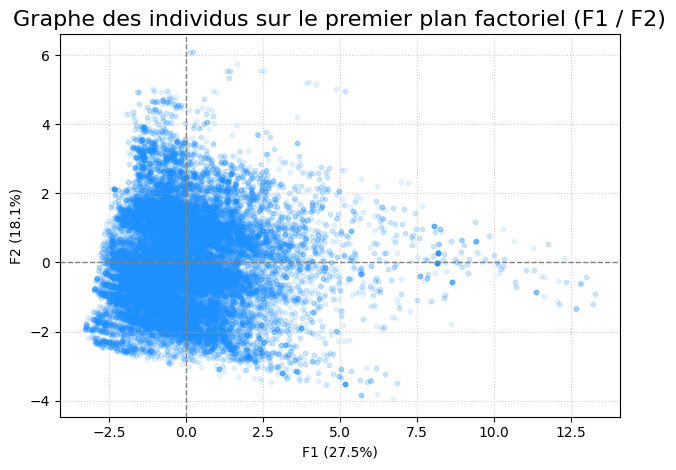

In [43]:
# On utilise un nuage de points avec une forte transparence (alpha=0.1) 
# pour bien voir les zones où les points se superposent
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.1, s=10, color='dodgerblue')

# 3. Esthétique
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Graphe des individus sur le premier plan factoriel (F1 / F2)", fontsize=16)
plt.xlabel(f"F1 ({var_f1:.1f}%)")
plt.ylabel(f"F2 ({var_f2:.1f}%)")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 6. Interprétation du Cercle des Corrélations (ACP)
L'analyse visuelle du cercle des corrélations sur les axes F1 et F2 nous permet de tirer des conclusions décisives :
* **Lien Agronomie-Géographie-Contamination** : Les variables `Taux_Chlordecone`, `histoBanane_Histo_ban` et la coordonnée `Y` (Latitude) pointent dans la même direction (quadrant supérieur droit). À l'inverse, la coordonnée `X` (Longitude) s'y oppose. Cela signifie que les zones historiquement riches en bananeraies, situées vers le **Nord-Ouest** du territoire, sont les plus contaminées.
* **Indépendance de la topographie** : Le groupe de variables topographiques (`mnt_pente`, `mnt_rugosite`, etc.) forme un angle quasiment droit (orthogonal) avec notre variable cible. La configuration du terrain n'a donc pas d'impact significatif sur la présence de chlordécone.